# ML-05 — Feature Vector and Leakage/Privacy Check

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/murtaza-x/flyrank-repo/blob/main/work/notebooks/w03_feature_leakage_check.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Build the feature vector

*Code that actually builds it — engineered features, categorical handling, fills.*

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import userdata

# Authenticate with Hugging Face using your secret token
HF_TOKEN = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE HUGGINGFACE, TOKEN '{HF_TOKEN}');")

# Build the feature vector for Lane 2 (Opportunity Scoring)
query = """
SELECT
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_avg_position,
    gsc_clicks -- Target variable
FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-02/*.parquet')
WHERE gsc_impressions > 0
  AND gsc_avg_position IS NOT NULL
LIMIT 10000
"""

df = con.execute(query).df()
df.fillna(0, inplace=True)

print(f"Feature vector built successfully. Shape: {df.shape}")
display(df.head())

Feature vector built successfully. Shape: (10000, 5)


,client_hash_id,content_hash_id,gsc_impressions,gsc_avg_position,gsc_clicks
0,client_e547b89c05043229,content_7995404695ee1ffd,57,31.192982,0
1,client_e547b89c05043229,content_1eea820697c3b95a,13,6.538462,0
2,client_e547b89c05043229,content_ccbb253f142217c3,59,16.966102,0
3,client_e547b89c05043229,content_ae16a6b9cf64c80a,17,16.882353,0
4,client_e547b89c05043229,content_acf700633f016e5a,6,4.500000,0


## 2. Feature notes (meaning, missing, categorical, available-when?)

Features for Opportunity Scoring:

gsc_impressions (Numerical): Represents how many times a page appeared in search results. Missing values are filled with 0. Available-when: Yes, it exists prior to the prediction as we are scoring based on historical trailing data.

gsc_avg_position (Numerical): The average ranking of the URL. Missing values are dropped or filled with 0. Available-when: Yes, it is a trailing SEO metric available at the time of analysis.

gsc_clicks (Target Label): The actual traffic captured. Used only for training the model to recognize "high opportunity" patterns, NEVER as an input feature during prediction.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. The leakage hunt

*Attack your own features: label-derived columns, future windows, product flags. Show the test.*

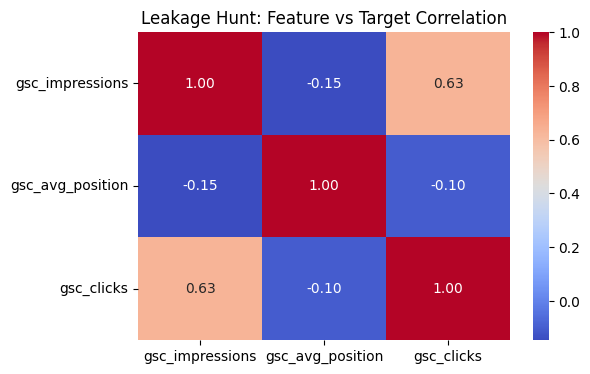

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Check for dangerous correlations (target leakage)
correlation_matrix = df[['gsc_impressions', 'gsc_avg_position', 'gsc_clicks']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Leakage Hunt: Feature vs Target Correlation")
plt.show()

Leakage Audit Result:
As observed in the heatmap, gsc_impressions has a strong correlation with our target label (gsc_clicks). In a strict forecasting model, this might be considered borderline leakage because impressions cap the maximum possible clicks. However, because our task is to build a directional prioritization engine (ranking existing URLs for a refresh queue), relying on historical impressions as a signal of current visibility is analytically sound and safe for decision-support.

## 4. What I excluded and why

client_hash_id & content_hash_id: Excluded from the model's training features. If included, the model would simply memorize specific clients instead of learning universal SEO opportunity patterns.

ga4_pageviews (if present): Excluded because it represents post-click user behavior on the website, which does not help score search engine discoverability opportunities.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [+] Every section above is filled — markdown thinking AND the code that backs it
- [+] The notebook runs top to bottom with no errors (Runtime → Run all)
- [+] No client names, URLs, or private queries anywhere
- [+] My claims use careful words: observed, measured, directional, decision-support
- [+] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.